# 数据清洗
## 主要任务
### 缺失值处理
- 填充属性的中心度量(均值或中位数)
- 填充最可能的值(回归,贝叶斯形式化方法)
### 噪声光滑
- 分箱(将数据排序并存放到相同大小的"桶"中),然后根据桶均值,桶中间值,桶边界值进行平滑
- 回归(如线性回归)
- 离群点分析(通过聚类之类的方法检测离群点)
### 异常值的检测与处理
#### 异常值的检测
- **简单统计**:最大最小值:如顾客年龄最大为300岁
- **3 $\sigma$ 原则**:如果数据取值超过了$\mu + 3\sigma$,认为存在偏差
- **箱型图**:利用箱型图的四分位距(IQR)对异常值进行检测
> 箱型图的几个数据:
>> 1. 上四分位数Q_3
>> 2. 下四分位数Q_1
>> 3. IQR:上四分位数减下四分位数
>> 4. 箱型图的两个横线分别是Q_3+1.5IQR和Q_1-1.5IQR
- **基于模型检测**:不能与模型完美拟合的点就是异常点
- **基于距离**:与其他对象原理的点
- **基于密度**:局部密度显著低于其他点的
- **基于聚类**:不属于任何簇的点
#### 异常值的处理
- 删除含有异常值的记录
- 将异常值视为缺失值
- 用平均值修正



均值为:-1.139986, 标准差为:102.965850
剔除异常值后数据点个数为:996


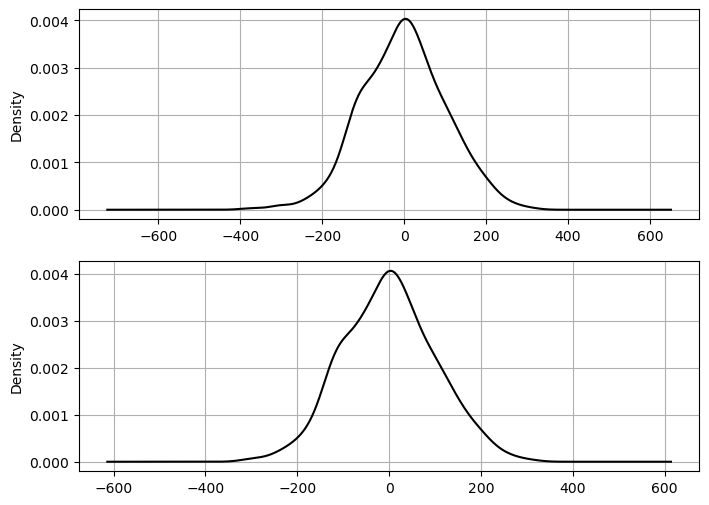

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

data = pd.Series(np.random.randn(1000)*100) #生成1000个随机数据点
u = data.mean() #计算均值
std = data.std() #计算标准差
stats.kstest(data, 'norm', args=(u, std)) #进行K-S检验
print('均值为:%f, 标准差为:%f' % (u, std))

# 绘制数据密度曲线
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(2, 1, 1) #添加子图1
data.plot(kind='kde',grid = True,style = '-k', ax=ax) #绘制核密度估计图

# 剔除异常值
ax_2 = fig.add_subplot(2, 1, 2) #添加子图2
data_no_outliers = data[(np.abs(data - u) <= 3 * std)] #剔除3倍标准差以外的异常值
data_no_outliers.plot(kind='kde',grid = True,style = '-k', ax=ax_2) #绘制剔除异常值后的核密度估计图
print('剔除异常值后数据点个数为:%d' % len(data_no_outliers))

# 数据集成

## 实体识别问题
- 问题:从不同数据源识别现实世界的实体,问题是处理语义的多样性和数据结构
> eg.苹果和apple都是一个东西,要识别为同一个
- 元数据:描述数据的数据,内容包括数据的名称,含义,数据类型和属性的值的允许范围,以及处理空值的规则

## 检测和解决数值冲突
- 问题来源:数据的比例,名称,编码,单位的不统一(如课程的评级,有的是a到c,有的是1到3)

## 冗余数据与相关性分析
- **数据集成往往导致数据冗余**
- 一个属性,如果能有另一个数据导出,则这个属性可能是多余的(如年收入和月收入)
- 属性间的冗余可以用相关分析检测然后删除
- 对于标称数据,使用卡方检测
- 对于数值属性,使用相关系数和协方差,他们都评估一个属性的值如何随另一个变化

## 元组重复
- 除了检测属性的冗余外,还应在元组级检测重复,例如,对唯一的给定数据实体,存在两个或多个相同的元组

- 不一致通常出现在不同的副本之间,由于不正确的输入或由于更新了数据副本的某些变化,例如,订单数据库的订货人可能以不同的地址出现1



# 数据规约
- 获得数据集的一个简约表示,使其在容量上大大减小,但仍接近保持源数据的完整性,并产生相同或基本相同的分析结果
- 用于规约的时间不应超过或抵消规约后数据挖掘节省的时间

## 策略1:维归约

### PCA主成分分析
- pca可以用于有序和无序的数据,可以处理稀疏和倾斜数据,多余二维的多维数据可以通过pca转化为2维数据,主成分可用作多元回归和聚类分析的输入

## 策略2:数量规约

### 参数化数据规约
- **线性回归模型**:将数据建模,拟合一条直线,用来近似给定数据,通常使用最小二乘法
- **对数线性模型**:给定n维元组的集合,可把每个元组看做n维空间的点
- 对于离散属性集,可用对数线性模型,基于维组合的一个较小子集,估计多维空间中每个点的概率
- 因此,对数线性模型也可用于维归约

### 非参数化数据归约

#### 直方图
- 分类:等宽直方图,等身/等频直方图
- 对于近似稀疏和稠密数据,以及高倾斜和均匀的数据,直方图是有效的

##### 聚类
- 聚类将元组看成对象,将对象划分为群和簇,使得在一个簇中的对象相互相似,与其他簇中的对象相异
- 在数据归约中,用数据的簇代替真实数据,其有效性依赖于数据的性质
##### 抽样
- 分类:无放回简单随机抽样,有放回简单随机抽样,簇抽样,分层抽样

#### 数据立方体聚集


# 数据变换
- 策略:平滑,聚集,属性构造,规范化,离散化,由标称数据产生概念分层

## 规范化

### min-max normalization
$v' = \frac{v_i - min_A}{max_A - min_A} \times (new\_ max_A - new\_ min_A)+new\_ min_A$
- 若今后输入数据超过原来的边界,有越界的风险

### z-score normalization
$v_i' = \frac{v_i-\overline{A}}{\sigma_A}$
- 当最大值和最小值未知,或孤立点左右了min-max的值时,该方法有用

### normalization by decimal scaling
- 通过移动小数点位置进行规范化,小数点的位数取决于a的最大绝对值

## 离散化
- 定义:将连续属性的范围分成区间,用来减少给定连续属性值的个数
- 为什么离散:有些分类算法只接受类别属性,减小数据大小

### 离散化分类

#### 无监督离散化

##### 等宽算法
- 若A和B是该属性的最高值和最低值,则区间的宽度为:W=(B-A)/N
- 受异常值影响
- 不能很好的处理偏离数据

##### 等频算法
- 将范围划分为N个区间,每个区间包含近似相等的数据样本
- 较好的数据比例

##### K-means聚类算法
- 用户指定离散化产生的区间数目K
- 随机找K个数据作为初始区间的中心
- 通过欧式距离分类
- 重新计算各区间的重心,并利用新重心重新聚类所有样本
- 逐步循环,直到重心不再改变

#### 监督离散化

##### 自上而下的卡方分裂算法
- 计算每个插入点的卡方值,当卡方值最大,作为分裂点,属性值被分为两块
- 计算卡方值,找到最大值将属性值域分为三块

##### ChiMerge算法
- 基于卡方值的自下而上的离散化方法

##### 标称数据的概念分层产生
- 标称数据:无穷多个值,值之间无序
- 概念分层:把数据变化到多个粒度值

